# Hands-on Image Classification Workshop

In this notebook you will recreate the core technology used in the visual heritage classifier on a public-image topic chosen by the workshop group.

Important: do not run the full notebook before preparing data. First, download images and place them into the class folders below.

The goal is simple: organize labeled images, train a lightweight classifier, and inspect the prediction confidence for every query/test image.

We will use:

- **HSV histograms** for color.
- **HOG descriptors** for shape and contours.
- **LBP histograms** for texture.
- **KNN with cosine distance** for classification.

No deep visual model is used in this workshop notebook.

## Notebook Navigation

1. [Correct Folder Structure](#correct-folder-structure)
2. [Optional Package Installation](#optional-package-installation)
3. [Imports and Paths](#imports-and-paths)
4. [Load the Labeled Images](#load-images)
5. [Preview the Dataset](#preview-dataset)
6. [Extract Classical Visual Features](#extract-features)
7. [Build Feature Tables](#build-feature-tables)
8. [Train the Classifier](#train-classifier)
9. [Evaluate the Classifier](#evaluate-classifier)
10. [Visualize One Prediction](#visualize-prediction)
11. [Save Workshop Outputs](#save-outputs)
12. [Try It Yourself](#try-it-yourself)

<a id="correct-folder-structure"></a>

## 1. Correct Folder Structure

Before running the notebook, download images and put them into class folders. The folder name is the label.

```text
workshop_materials/
  data/
    dataset_dev/
      01_class/
      02_class/
    dataset_test/
      01_class/
      02_class/
```

Rules:

- Add training examples to `data/dataset_dev/<class_name>/`.
- Add query/test images to `data/dataset_test/<class_name>/`.
- Use at least two class folders.
- If you rename folders, use the exact same names in both splits.
- Example: `dataset_dev/01_ceramics/` must match `dataset_test/01_ceramics/`.
- Do not use `dataset_dev/01_ceramics/` and `dataset_test/ceramics/` for the same class.
- If `dataset_test/` is empty, the notebook creates a validation split from `dataset_dev/`.

Suggested public image sources:

- The Fruits collection: https://www.kaggle.com/datasets/shreyapmaher/fruits-dataset-images

Easy workshop category pairs: ceramics vs textiles, paintings vs sculptures, coins vs manuscripts, birds vs insects.

For a short workshop, download 8-15 training images per class and 2-5 query/test images per class.

<a id="optional-package-installation"></a>

## 2. Optional Package Installation

If this notebook runs in a fresh environment, uncomment and run the next cell once.

In [15]:
# If packages are missing, remove the leading # from the next line and run this cell once.
# %pip install -q numpy pandas Pillow matplotlib scikit-image scikit-learn tqdm

<a id="imports-and-paths"></a>

## 3. Imports and Paths

This cell finds `workshop_materials/` automatically.

In [16]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
from tqdm.auto import tqdm

from skimage.color import rgb2gray
from skimage.feature import hog, local_binary_pattern
from sklearn.metrics import accuracy_score, confusion_matrix, top_k_accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


def find_workshop_dir() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        possible_locations = [
            candidate,
            candidate / "workshop_materials",
            candidate / "step_1" / "workshop_materials",
        ]
        for location in possible_locations:
            if (location / "data").exists() and (location / "notebooks").exists():
                return location.resolve()
    raise FileNotFoundError("Could not find workshop_materials/. Run this notebook from inside the repository.")


WORKSHOP_DIR = find_workshop_dir()
DATA_DIR = WORKSHOP_DIR / "data"
DEV_DIR = DATA_DIR / "dataset_dev"
TEST_DIR = DATA_DIR / "dataset_test"
OUTPUTS_DIR = WORKSHOP_DIR / "outputs"
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_SIZE = (96, 96)
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp", ".tif", ".tiff"}

print("Workshop folder:", WORKSHOP_DIR)
print("Development data:", DEV_DIR)
print("Test data:", TEST_DIR)
print("Outputs:", OUTPUTS_DIR)

Workshop folder: /Users/memerchik/Documents/GitHub/aister_intangible_visual/step_1/workshop_materials
Development data: /Users/memerchik/Documents/GitHub/aister_intangible_visual/step_1/workshop_materials/data/dataset_dev
Test data: /Users/memerchik/Documents/GitHub/aister_intangible_visual/step_1/workshop_materials/data/dataset_test
Outputs: /Users/memerchik/Documents/GitHub/aister_intangible_visual/step_1/workshop_materials/outputs


<a id="load-images"></a>

## 4. Load the Labeled Images

The class label comes from the folder name. `dataset_dev/` is used for training; `dataset_test/` contains the query/test images we want to inspect.

In [17]:
def is_image_file(path: Path) -> bool:
    return path.suffix.lower() in IMAGE_EXTENSIONS


def collect_records(split_dir: Path, split_name: str) -> pd.DataFrame:
    rows = []
    if not split_dir.exists():
        return pd.DataFrame(rows)
    for class_dir in sorted(path for path in split_dir.iterdir() if path.is_dir()):
        if class_dir.name.startswith("."):
            continue
        class_name = class_dir.name
        for image_path in sorted(class_dir.rglob("*")):
            if image_path.is_file() and is_image_file(image_path):
                rows.append({
                    "split": split_name,
                    "class_name": class_name,
                    "file_name": image_path.name,
                    "image_path": str(image_path.resolve()),
                })
    return pd.DataFrame(rows)


dev_records = collect_records(DEV_DIR, "dataset_dev")
provided_test_records = collect_records(TEST_DIR, "dataset_test")

if dev_records.empty:
    raise ValueError("No development images found. Add images under data/dataset_dev/<class_name>/.")

if dev_records["class_name"].nunique() < 2:
    raise ValueError("Add images for at least two classes before training a classifier.")

class_counts = dev_records["class_name"].value_counts().sort_index()
if class_counts.min() < 2:
    print("Warning: at least one class has fewer than 2 training images. Add more images for a more reliable workshop result.")

dev_classes = sorted(dev_records["class_name"].unique())
test_classes = sorted(provided_test_records["class_name"].unique()) if not provided_test_records.empty else []
unknown_test_classes = sorted(set(test_classes) - set(dev_classes))
if unknown_test_classes:
    raise ValueError(
        "These dataset_test folders do not exist in dataset_dev: "
        + ", ".join(unknown_test_classes)
        + ". Rename them so class folder names match exactly."
    )

missing_test_classes = sorted(set(dev_classes) - set(test_classes))
if test_classes and missing_test_classes:
    print("Note: no query/test images found for these training classes:", missing_test_classes)

print(f"Development images: {len(dev_records)}")
print(f"Development classes: {dev_records['class_name'].nunique()}")
print(f"Provided test images: {len(provided_test_records)}")

dataset_summary = pd.concat([dev_records, provided_test_records], ignore_index=True)
dataset_summary = dataset_summary.groupby(["split", "class_name"]).size().reset_index(name="image_count")
display(dataset_summary)

Development images: 314
Development classes: 9
Provided test images: 45


,split,class_name,image_count
0,dataset_dev,apple,35
1,dataset_dev,banana,35
2,dataset_dev,cherry,35
3,dataset_dev,chickoo,35
4,dataset_dev,grapes,35
5,dataset_dev,kiwi,35
6,dataset_dev,mango,34
7,dataset_dev,orange,35
8,dataset_dev,strawberry,35
9,dataset_test,apple,5


<a id="preview-dataset"></a>

## 5. Preview the Dataset

Use this to check that the notebook reads the expected images.

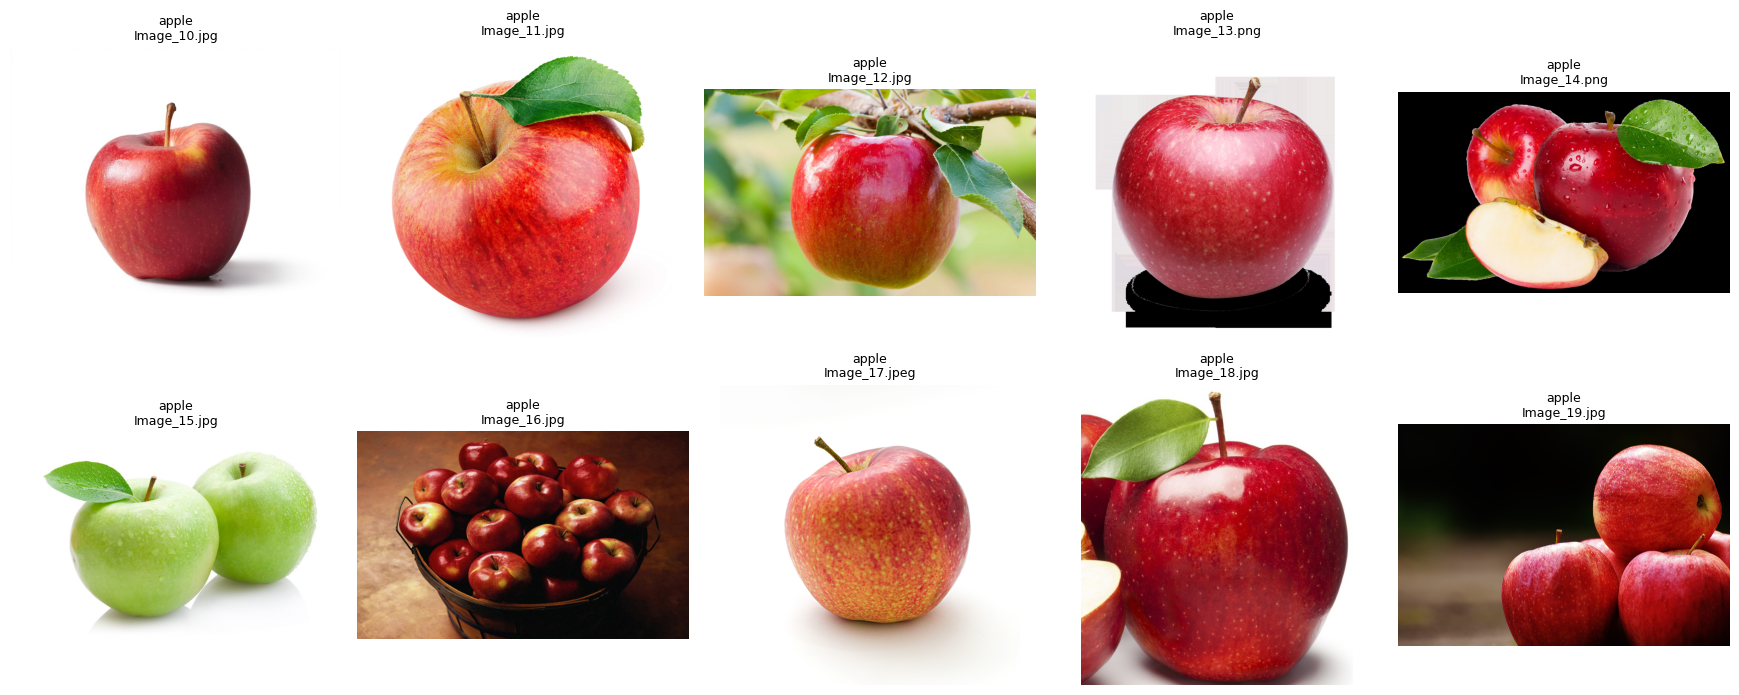

In [18]:
def load_rgb(path, image_size=None):
    with Image.open(path) as image:
        image = ImageOps.exif_transpose(image).convert("RGB")
        if image_size is not None:
            image = image.resize(image_size)
        return image


def show_image_grid(records: pd.DataFrame, max_images: int = 10):
    sample = records.head(max_images)
    cols = min(5, len(sample))
    rows = int(np.ceil(len(sample) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3.5 * cols, 3.5 * rows))
    axes = np.array(axes).reshape(-1)
    for ax in axes:
        ax.axis("off")
    for axis, row in zip(axes, sample.itertuples()):
        axis.imshow(load_rgb(Path(row.image_path)))
        axis.set_title(f"{row.class_name}\n{row.file_name}", fontsize=9)
    plt.tight_layout()
    plt.show()


show_image_grid(dev_records, max_images=10)

<a id="extract-features"></a>

## 6. Extract Classical Visual Features

Each image becomes one feature vector made from color, shape, and texture.

In [19]:
def normalize_histogram(values: np.ndarray) -> np.ndarray:
    total = values.sum()
    return values / total if total > 0 else values


def extract_hsv_histogram(rgb: np.ndarray) -> np.ndarray:
    hsv = np.asarray(Image.fromarray((rgb * 255).astype(np.uint8)).convert("HSV"), dtype="float32") / 255.0
    hist, _ = np.histogramdd(
        hsv.reshape(-1, 3),
        bins=(8, 8, 8),
        range=((0, 1), (0, 1), (0, 1)),
    )
    return normalize_histogram(hist.astype("float32").ravel())


def extract_hog_descriptor(gray: np.ndarray) -> np.ndarray:
    return hog(
        gray,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        feature_vector=True,
    ).astype("float32")


def extract_lbp_histogram(gray: np.ndarray) -> np.ndarray:
    points = 8
    radius = 1
    lbp = local_binary_pattern((gray * 255).astype(np.uint8), points, radius, method="uniform")
    hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, points + 3), range=(0, points + 2))
    return normalize_histogram(hist.astype("float32"))


def extract_features(image_path, image_size=IMAGE_SIZE):
    image = load_rgb(image_path, image_size=image_size)
    rgb = np.asarray(image, dtype="float32") / 255.0
    gray = rgb2gray(rgb)
    color = extract_hsv_histogram(rgb)
    shape = extract_hog_descriptor(gray)
    texture = extract_lbp_histogram(gray)
    return np.concatenate([color, shape, texture]).astype("float32")


example_vector = extract_features(Path(dev_records.iloc[0]["image_path"]))
print("Feature vector length:", len(example_vector))

Feature vector length: 1422


<a id="build-feature-tables"></a>

## 7. Build Feature Tables

Now every image is converted into numbers the classifier can use.

In [20]:
def build_feature_matrix(records: pd.DataFrame) -> np.ndarray:
    vectors = []
    for row in tqdm(records.itertuples(), total=len(records), desc="Extracting features"):
        vectors.append(extract_features(Path(row.image_path)))
    return np.vstack(vectors).astype("float32")


if provided_test_records.empty:
    counts = dev_records["class_name"].value_counts()
    if counts.min() < 2:
        raise ValueError("If dataset_test is empty, add at least 2 training images per class so the notebook can create a validation split.")
    validation_size = max(len(counts), int(np.ceil(len(dev_records) * 0.25)))
    if validation_size >= len(dev_records):
        raise ValueError("Add more training images, or place separate query/test images in dataset_test/.")
    train_records, test_records = train_test_split(
        dev_records,
        test_size=validation_size,
        random_state=42,
        stratify=dev_records["class_name"],
    )
    split_note = "Created validation split from dataset_dev."
else:
    train_records = dev_records.copy()
    test_records = provided_test_records.copy()
    split_note = "Using provided dataset_test split."

X_train = build_feature_matrix(train_records)
X_test = build_feature_matrix(test_records)
y_train = train_records["class_name"].to_numpy()
y_test = test_records["class_name"].to_numpy()
class_names = sorted(train_records["class_name"].unique())

print(split_note)
print("Train features:", X_train.shape)
print("Test features:", X_test.shape)

Extracting features: 100%|██████████| 45/45 [00:01<00:00, 24.78it/s]

Using provided dataset_test split.
Train features: (314, 1422)
Test features: (45, 1422)


<a id="train-classifier"></a>

## 8. Train the Classifier

We use the same idea as the prototype: cosine-distance KNN on the combined feature vector.

In [21]:
n_neighbors = min(5, len(train_records))

classifier = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=n_neighbors, metric="cosine", weights="distance")),
])

classifier.fit(X_train, y_train)

print(f"Trained KNN classifier with k={n_neighbors}.")

Trained KNN classifier with k=5.


<a id="evaluate-classifier"></a>

## 9. Evaluate the Classifier

Top-1 accuracy checks the first prediction. The prediction table shows every query/test image and one confidence column per class.

These confidence values come from distance-weighted KNN voting, so treat them as model confidence scores rather than perfect statistical probabilities.

In [22]:
probabilities = classifier.predict_proba(X_test)
model_classes = list(classifier.classes_)
top_order = np.argsort(-probabilities, axis=1)
predicted = np.array([model_classes[indexes[0]] for indexes in top_order])
confidence_columns = [f"confidence__{class_name}" for class_name in model_classes]


def top_label(row_index: int, rank: int):
    if rank >= len(model_classes):
        return None, None
    class_index = top_order[row_index, rank]
    return model_classes[class_index], float(probabilities[row_index, class_index])


prediction_rows = []
for row_index, record in enumerate(test_records.reset_index(drop=True).itertuples()):
    top1, top1_score = top_label(row_index, 0)
    top2, top2_score = top_label(row_index, 1)
    top3, top3_score = top_label(row_index, 2)
    row_data = {
        "file_name": record.file_name,
        "image_path": record.image_path,
        "true_class": record.class_name,
        "predicted_class": top1,
        "top_1_class": top1,
        "top_2_class": top2,
        "top_3_class": top3,
        "top_1_confidence": top1_score,
        "top_2_confidence": top2_score,
        "top_3_confidence": top3_score,
        "is_correct": bool(top1 == record.class_name),
    }
    for class_index, class_name in enumerate(model_classes):
        row_data[f"confidence__{class_name}"] = float(probabilities[row_index, class_index])
    prediction_rows.append(row_data)

predictions_df = pd.DataFrame(prediction_rows)
accuracy = accuracy_score(y_test, predicted)
top3_accuracy = None
if len(model_classes) >= 3:
    top3_accuracy = float(top_k_accuracy_score(y_test, probabilities, k=3, labels=model_classes))
confusion = confusion_matrix(y_test, predicted, labels=class_names)

metrics = {
    "model": "knn_cosine",
    "n_neighbors": int(n_neighbors),
    "feature_set": "HSV + HOG + LBP",
    "image_size": list(IMAGE_SIZE),
    "train_examples": int(len(train_records)),
    "test_examples": int(len(test_records)),
    "test_accuracy": float(accuracy),
    "test_top_3_accuracy": top3_accuracy,
    "classes": class_names,
}

display_columns = [
    "file_name",
    "true_class",
    "predicted_class",
    "is_correct",
    "top_1_confidence",
    "top_2_class",
    "top_2_confidence",
    "top_3_class",
    "top_3_confidence",
    *confidence_columns,
]

print(f"Accuracy: {accuracy:.2%}")
if top3_accuracy is not None:
    print(f"Top-3 accuracy: {top3_accuracy:.2%}")
else:
    print("Top-3 accuracy skipped because the dataset has fewer than 3 classes.")

with pd.option_context("display.max_rows", len(predictions_df), "display.max_columns", None):
    display(predictions_df[display_columns])

Accuracy: 64.44%
Top-3 accuracy: 82.22%


,file_name,true_class,predicted_class,is_correct,top_1_confidence,top_2_class,top_2_confidence,top_3_class,top_3_confidence,confidence__apple,confidence__banana,confidence__cherry,confidence__chickoo,confidence__grapes,confidence__kiwi,confidence__mango,confidence__orange,confidence__strawberry
0,Image_1.jpg,apple,apple,True,1.000000,banana,0.000000,cherry,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,Image_2.jpg,apple,apple,True,0.627891,orange,0.186190,strawberry,0.185919,0.627891,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.186190,0.185919
2,Image_3.jpeg,apple,apple,True,0.793783,orange,0.105146,kiwi,0.101071,0.793783,0.000000,0.000000,0.000000,0.000000,0.101071,0.000000,0.105146,0.000000
3,Image_4.jpg,apple,apple,True,0.804059,orange,0.195941,banana,0.000000,0.804059,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.195941,0.000000
4,Image_5.jpg,apple,apple,True,0.820353,orange,0.179647,banana,0.000000,0.820353,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.179647,0.000000
5,Image_1.jpg,banana,banana,True,1.000000,apple,0.000000,cherry,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,Image_2.jpg,banana,banana,True,0.992627,kiwi,0.003943,mango,0.001723,0.000000,0.992627,0.000000,0.001706,0.000000,0.003943,0.001723,0.000000,0.000000
7,Image_3.jpeg,banana,banana,True,1.000000,apple,0.000000,cherry,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,Image_4.JPG,banana,banana,True,1.000000,apple,0.000000,cherry,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
9,Image_5.jpg,banana,banana,True,1.000000,apple,0.000000,cherry,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


<a id="visualize-prediction"></a>

## 10. Visualize One Prediction

Use this cell to inspect one query/test image and compare confidence across all classes.

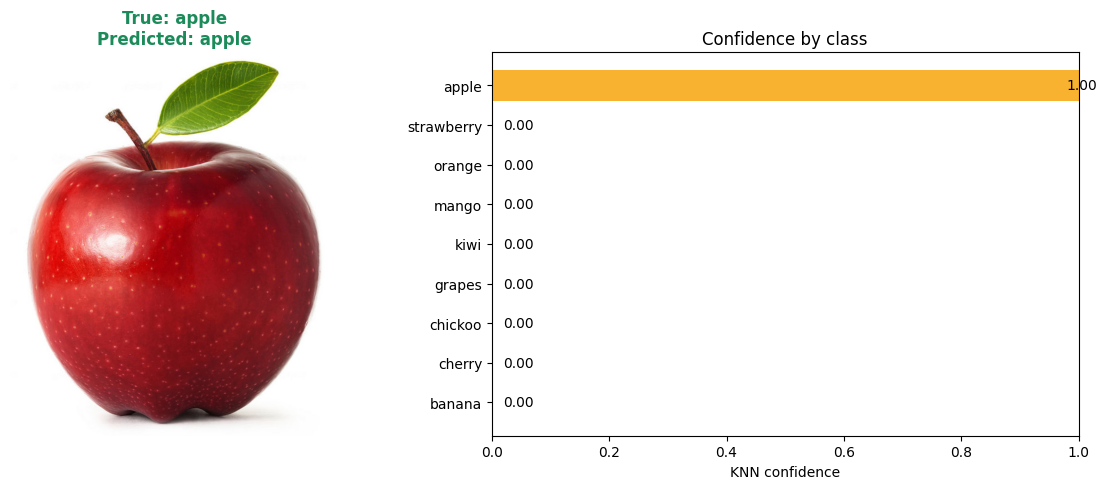

,class,confidence
0,apple,1.0
1,banana,0.0
2,cherry,0.0
3,chickoo,0.0
4,grapes,0.0
5,kiwi,0.0
6,mango,0.0
7,orange,0.0
8,strawberry,0.0


In [23]:
PALETTE = {
    "blue": "#071951",
    "coral": "#ff5757",
    "orange": "#f9b22f",
    "green": "#1c8b5a",
}


def show_prediction(row_number: int = 0):
    row = predictions_df.iloc[row_number]
    correct = bool(row["is_correct"])
    title_color = PALETTE["green"] if correct else PALETTE["coral"]
    confidence_df = pd.DataFrame({
        "class": model_classes,
        "confidence": [row[f"confidence__{class_name}"] for class_name in model_classes],
    }).sort_values("confidence", ascending=True)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [1, 1.2]})
    axes[0].imshow(load_rgb(Path(row["image_path"])))
    axes[0].axis("off")
    axes[0].set_title(
        f"True: {row['true_class']}\nPredicted: {row['predicted_class']}",
        color=title_color,
        fontsize=12,
        fontweight="bold",
    )

    bar_colors = [PALETTE["orange"] if value == confidence_df["confidence"].max() else PALETTE["blue"] for value in confidence_df["confidence"]]
    axes[1].barh(confidence_df["class"], confidence_df["confidence"], color=bar_colors)
    axes[1].set_xlim(0, 1)
    axes[1].set_xlabel("KNN confidence")
    axes[1].set_title("Confidence by class")
    for index, value in enumerate(confidence_df["confidence"]):
        axes[1].text(min(value + 0.02, 0.98), index, f"{value:.2f}", va="center")
    plt.tight_layout()
    plt.show()

    display(confidence_df.sort_values("confidence", ascending=False))


show_prediction(0)

<a id="save-outputs"></a>

## 11. Save Workshop Outputs

The outputs are useful for comparing results after changing the dataset.

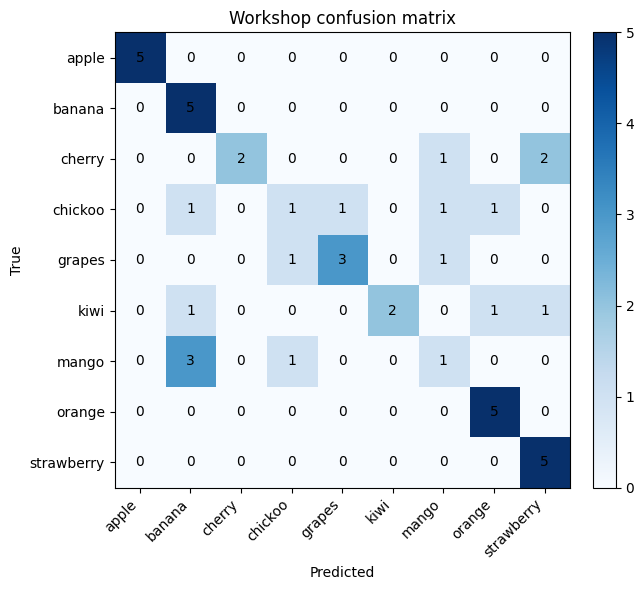

Saved workshop outputs to: /Users/memerchik/Documents/GitHub/aister_intangible_visual/step_1/workshop_materials/outputs


In [ ]:
predictions_df.to_csv(OUTPUTS_DIR / "workshop_predictions.csv", index=False)
dataset_summary.to_csv(OUTPUTS_DIR / "workshop_dataset_summary.csv", index=False)
pd.DataFrame(confusion, index=class_names, columns=class_names).to_csv(OUTPUTS_DIR / "workshop_confusion_matrix.csv")

with open(OUTPUTS_DIR / "workshop_metrics.json", "w", encoding="utf-8") as handle:
    json.dump(metrics, handle, indent=2)

fig, axis = plt.subplots(figsize=(7, 6))
image = axis.imshow(confusion, cmap="Blues")
axis.set_xticks(range(len(class_names)))
axis.set_yticks(range(len(class_names)))
axis.set_xticklabels(class_names, rotation=45, ha="right")
axis.set_yticklabels(class_names)
axis.set_xlabel("Predicted")
axis.set_ylabel("True")
axis.set_title("Workshop confusion matrix")
for row_index in range(confusion.shape[0]):
    for col_index in range(confusion.shape[1]):
        axis.text(col_index, row_index, confusion[row_index, col_index], ha="center", va="center")
fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "workshop_confusion_matrix.png", dpi=180)
plt.show()

#print("Saved workshop outputs to:", OUTPUTS_DIR)

<a id="try-it-yourself"></a>

## 12. Try It Yourself

Workshop exercise:

1. Choose at least two visual categories.
2. Rename `01_class` and `02_class` if useful.
3. Add training images to matching folders in `data/dataset_dev/`.
4. Add query/test images to the same folder names in `data/dataset_test/`.
5. Run the notebook from **Load the Labeled Images** onward.
6. Inspect the prediction table and confidence columns for every query/test image.

Things to test:

- Do color-heavy categories work better?
- Do texture-heavy categories confuse the classifier?
- What changes when you add more examples?
- Which classes are visually similar?

The key idea: classical image features can create a transparent baseline before using larger AI models.